In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [2]:
dataset_df = pd.read_csv('../dataset/open-meteo_newDataset.csv')
datasun_df = pd.read_csv('../dataset/open-meteo_sunriseSunset.csv')

In [3]:
datasun_df['sunrise'] = pd.to_datetime(datasun_df['sunrise']).dt.time
datasun_df['sunset'] = pd.to_datetime(datasun_df['sunset']).dt.time
datasun_df['date'] = pd.to_datetime(datasun_df['date']).dt.date


In [4]:
datasun_df.head()

,date,sunrise,sunset
0,2019-01-23,06:39:00,17:31:00
1,2019-01-24,06:39:00,17:32:00
2,2019-01-25,06:39:00,17:32:00
3,2019-01-26,06:38:00,17:33:00
4,2019-01-27,06:38:00,17:34:00


In [5]:
def time_to_decimal(t):
    return (t.hour + t.minute / 60.0 + t.second / 3600.0) * 24 / 24

In [6]:
datasun_df['sunrise'] = datasun_df['sunrise'].apply(lambda x: time_to_decimal(x))
datasun_df['sunset'] = datasun_df['sunset'].apply(lambda x: time_to_decimal(x))

In [7]:
datasun_df.head()

,date,sunrise,sunset
0,2019-01-23,6.650000,17.516667
1,2019-01-24,6.650000,17.533333
2,2019-01-25,6.650000,17.533333
3,2019-01-26,6.633333,17.550000
4,2019-01-27,6.633333,17.566667


In [8]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['date'] = dataset_df['time'].dt.date
dataset_df['time'] = pd.to_datetime(dataset_df['time'], format='%H:%M:%S').dt.hour.astype(float)

In [9]:
dataset_df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²),date
0,0.0,10.1,84,7.4,8.2,0.0,5,4,2,0,0.0,0.20,0.0,0.0,0.0,0.0,0.0,2019-01-23
1,1.0,9.7,84,7.2,7.7,0.0,4,4,1,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0,2019-01-23
2,2.0,9.6,84,7.0,7.5,0.0,10,10,2,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0,2019-01-23
3,3.0,9.6,84,7.0,7.5,0.0,29,29,4,0,0.0,0.19,0.0,0.0,0.0,0.0,0.0,2019-01-23
4,4.0,10.3,81,7.1,8.4,0.0,35,34,6,0,0.0,0.24,0.0,0.0,0.0,0.0,0.0,2019-01-23


In [10]:
sun_dict = datasun_df.set_index('date')[['sunrise','sunset']].to_dict('index')

In [11]:
normalized_hours = []

for idx, row in dataset_df.iterrows():
    row_time = row['time']
    row_date = row['date']

    if row_date in sun_dict:
        sr = sun_dict[row_date]['sunrise']
        ss = sun_dict[row_date]['sunset']

        if sr <= row_time <= ss: #daytime (normalized antara 0 dan 1)
            norm_hour = (row_time - sr) / (ss - sr)
        else: #night time
            if row_time > ss:
                norm_hour = (row_time - ss) / (24 - ss + sr)
            else:
                norm_hour = (row_time + (24 - ss)) / (24 - ss + sr)

        normalized_hours.append(norm_hour)

In [12]:
dataset_df['normalized_hour'] = normalized_hours

In [13]:
dataset_df['sin_daytime'] = np.sin(2 * np.pi * dataset_df['normalized_hour']) 
dataset_df['cos_daytime'] = np.cos(2 * np.pi * dataset_df['normalized_hour']) 

In [14]:
dataset_df.to_csv("dataset_hour.csv", index=False)

In [15]:
dataset_df['date'] = pd.to_datetime(dataset_df['date'])
dataset_df['month'] = dataset_df['date'].dt.month

# Pisahkan data berdasarkan bulan
january_df = dataset_df[dataset_df['month'] == 1]
february_df = dataset_df[dataset_df['month'] == 2]
march_df = dataset_df[dataset_df['month'] == 3]
april_df = dataset_df[dataset_df['month'] == 4]
may_df = dataset_df[dataset_df['month'] == 5]
june_df = dataset_df[dataset_df['month'] == 6]
july_df = dataset_df[dataset_df['month'] == 7]
august_df = dataset_df[dataset_df['month'] == 8]
september_df = dataset_df[dataset_df['month'] == 9]
october_df = dataset_df[dataset_df['month'] == 10]
november_df = dataset_df[dataset_df['month'] == 11]
december_df = dataset_df[dataset_df['month'] == 12]

In [16]:
january_df.set_index('time', inplace=True)
february_df.set_index('time', inplace=True)
march_df.set_index('time', inplace=True)
april_df.set_index('time', inplace=True)
may_df.set_index('time', inplace=True)
june_df.set_index('time', inplace=True)
july_df.set_index('time', inplace=True)
august_df.set_index('time', inplace=True)
september_df.set_index('time', inplace=True)
october_df.set_index('time', inplace=True)
november_df.set_index('time', inplace=True)
december_df.set_index('time', inplace=True)

# January

## Preprocessing

In [17]:
data_features = january_df[['sin_daytime', 'cos_daytime', 'shortwave_radiation_instant (W/m²)', 'et0_fao_evapotranspiration (mm)', 'vapour_pressure_deficit (kPa)', 'relative_humidity_2m (%)', 'temperature_2m (°C)', 'apparent_temperature (°C)', 'rain (mm)', 'cloud_cover_low (%)']].values

data_target = january_df['shortwave_radiation_instant (W/m²)'].values

In [18]:
print(len(data_features))

240


In [19]:
look_back = 120 #menggunakan timestamp 24
n_ahead = 12 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 24 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

In [20]:
print(x_seq.shape)
print(y_seq.shape)

(109, 120, 10)
(109, 12)


In [21]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (87, 120, 10), x_test shape: (22, 120, 10)
y_train shape: (1044,), y_test shape: (264,)


In [22]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2]) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, x_train.shape[2])).reshape(x_test.shape[0], x_test.shape[1], x_train.shape[2])
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (87, 120, 10), X_test_scaled shape: (22, 120, 10)
y_train_scaled shape: (87, 12), y_test_scaled shape: (22, 12)


## Build Model

In [23]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [24]:
class ExpandDims(keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super(ExpandDims, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

In [25]:
def build_model(
    n_input: int,
    n_output: int,
    num_features: int,
    head_size: int,
    num_heads: int,
    ff_dim: int,
    num_transformer_blocks: int,
    mlp_units,              
    dropout=0.1,            # slightly smaller dropout
    mlp_dropout=0.1
):
    inputs = keras.Input(shape=(n_input, num_features))
    x = inputs
    
    # --- LSTM Encoder ---
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x) 
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_encoder_hidden1"
    )(x)
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_encoder_hidden2"
    )(x)
    x = keras.layers.Dropout(dropout)(x)
    x, state_h, state_c = keras.layers.LSTM(
        units=32, return_sequences=True, return_state=True, name="lstm_encoder"
    )(x)
    
    # --- Transformer Encoder Blocks ---
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    # Pool & reshape before decoder
    x = keras.layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = ExpandDims(axis=1)(x)
    
    # --- LSTM Decoder ---
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_decoder1"
    )(x, initial_state=[state_h, state_c])
    
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LSTM(
        units=32, return_sequences=False, name="lstm_decoder_final"
    )(x)
    
    # --- MLP “head” ---
    for dim in mlp_units:
        x = keras.layers.Dense(dim, activation="relu")(x)
        x = keras.layers.Dropout(mlp_dropout)(x)

    # Use 'relu' if target is strictly nonnegative
    outputs = keras.layers.Dense(n_output, activation="relu")(x)
    
    return keras.Model(inputs, outputs)

In [26]:
class PredictionComparisonCallback(keras.callbacks.Callback):
    def __init__(self, x_val, y_val, n_samples=5):
        super(PredictionComparisonCallback, self).__init__()
        self.x_val = x_val
        self.y_val = y_val
        self.n_samples = n_samples  # jumlah sampel yang ingin dibandingkan tiap epoch

    def on_epoch_end(self, epoch, logs=None):
        predictions = self.model.predict(self.x_val)
        print(f"\nEpoch {epoch+1} - Perbandingan Prediksi vs Aktual:")
        for i in range(min(self.n_samples, len(self.x_val))):
            print(f"Sample {i}: Prediksi = {predictions[i]}, Aktual = {self.y_val[i]}")


## Train and Evaluate

In [27]:
model = build_model(
    n_input=look_back,
    n_output=n_ahead,
    num_features=x_train_scaled.shape[2],
    head_size=64,
    num_heads=4,
    ff_dim=10,                    # increased
    num_transformer_blocks=4, 
    mlp_units=[32, 16],          # deeper MLP
    mlp_dropout=0.1,
    dropout=0.1
)

optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    loss="mean_squared_error",
    optimizer=optimizer,
    metrics=[
        "mae",
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsolutePercentageError(name="mape")
    ]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 120, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 120, 10)   │         20 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 120, 32)   │      5,504 │ layer_normalizat… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 120, 32)   │      8,320 │ lstm_encoder_hid… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 120, 32)   │          0 │ lstm_encoder_hid… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ [(None, 120, 32), │      8,320 │ dropout[0][0]     │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 32)   │     33,568 │ lstm_encoder[0][… │
│ (MultiHeadAttentio… │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 120, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 32)   │         64 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 120, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 120, 10)   │        330 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 120, 10)   │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 120, 32)   │        352 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 32)   │         64 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 120, 32)   │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 120, 32)   │     33,568 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 120, 32)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 120, 32)   │         64 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 178,168 (695.97 KB)

 Trainable params: 178,168 (695.97 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
split_idx = int(0.8 * len(x_train_scaled))
x_train_manual, x_val = x_train_scaled[:split_idx], x_train_scaled[split_idx:]
y_train_manual, y_val = y_train_scaled[:split_idx], y_train_scaled[split_idx:]

comparison_callback = PredictionComparisonCallback(x_val, y_val, n_samples=3)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6
)

model.fit(
    x_train_manual, y_train_manual,
    validation_data=(x_val, y_val),
    epochs=200,
    batch_size=20,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        comparison_callback,
        lr_scheduler
    ]
)

model.evaluate(x_test_scaled, y_test_scaled, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step- loss: 0.6188 - mae: 0.4985 - mape: 18511562.0000 - rmse: 0.786

Epoch 1 - Perbandingan Prediksi vs Aktual:
Sample 0: Prediksi = [0.15777981 0.28416905 0.21805283 0.         0.07716115 0.10561844
 0.01616521 0.21928313 0.         0.         0.20941104 0.        ], Aktual = [ 0.          0.          0.         -0.01984593 -0.01984593 -0.01984593
 -0.01984593 -0.01984593  0.          0.          0.03406326  0.52789524]
Sample 1: Prediksi = [0.15802082 0.2847546  0.21840543 0.         0.07744546 0.1052334
 0.0157228  0.22010036 0.         0.         0.20789471 0.        ], Aktual = [ 0.          0.          0.         -0.01984593 -0.01984593 -0.01984593
 -0.01984593 -0.01984593  0.          0.03290247  0.52311436  0.99167917]
Sample 2: Prediksi = [0.15816839 0.2860465  0.21864085 0.         0.07799508 0.10439827
 0.01566185 0.22133115 0.         0.         0.20576392 0.        ], Aktual = [ 0.          0.          0.         -0.01984593 -

[0.14988289773464203, 0.23413020372390747, 0.38714712858200073, 23165088.0]

## Predict

In [29]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assume y_test_scaled, y_pred_scaled, y_test, y_pred are defined

# Calculate MAE and MSE for scaled values
mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
mse_scaled = mean_squared_error(y_test_scaled, y_pred_scaled)
print(f'Mean Absolute Error (MAE) Scaled: {mae_scaled}')
print(f'Mean Squared Error (MSE) Scaled: {mse_scaled}')

# Calculate MAE and MSE for true values
mae_true = mean_absolute_error(y_test, y_pred)
mse_true = mean_squared_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE) True Value: {mae_true}')
print(f'Mean Squared Error (MSE) True Value: {mse_true}')

# Define a function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero by adding a small epsilon where y_true is 0 if needed.
    epsilon = np.finfo(np.float64).eps
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

# Calculate MAPE for both scaled and true values
mape_scaled = mean_absolute_percentage_error(y_test_scaled, y_pred_scaled)
mape_true = mean_absolute_percentage_error(y_test, y_pred)
print(f'MAPE (Scaled): {mape_scaled:.2f}%')
print(f'MAPE (True Values): {mape_true:.2f}%')

# Compare the MAE (true values) with the standard deviation of the true values
std_true = np.std(y_test)
print(f'Standard Deviation of True Values: {std_true:.2f}')

print('\n')
print(f'Standard Deviation of True Values: {std_true:.2f} vs Mean Absolute Error (MAE) True Value: {mae_true}')
if mae_true < std_true:
    print("The model's MAE is lower than the standard deviation of the true values, which suggests the model's errors are relatively small compared to the data's variability.")
else:
    print("The model's MAE is higher than the standard deviation of the true values, indicating that the model's errors might be too high relative to the natural spread of the data.")

Mean Absolute Error (MAE) Scaled: 0.23413020935336612
Mean Squared Error (MSE) Scaled: 0.149882897215511
Mean Absolute Error (MAE) True Value: 88.5176413438537
Mean Squared Error (MSE) True Value: 21168.505038148553
MAPE (Scaled): 10432531550381984.00%
MAPE (True Values): 6040889647247384576.00%
Standard Deviation of True Values: 103.74


Standard Deviation of True Values: 103.74 vs Mean Absolute Error (MAE) True Value: 88.5176413438537
The model's MAE is lower than the standard deviation of the true values, which suggests the model's errors are relatively small compared to the data's variability.


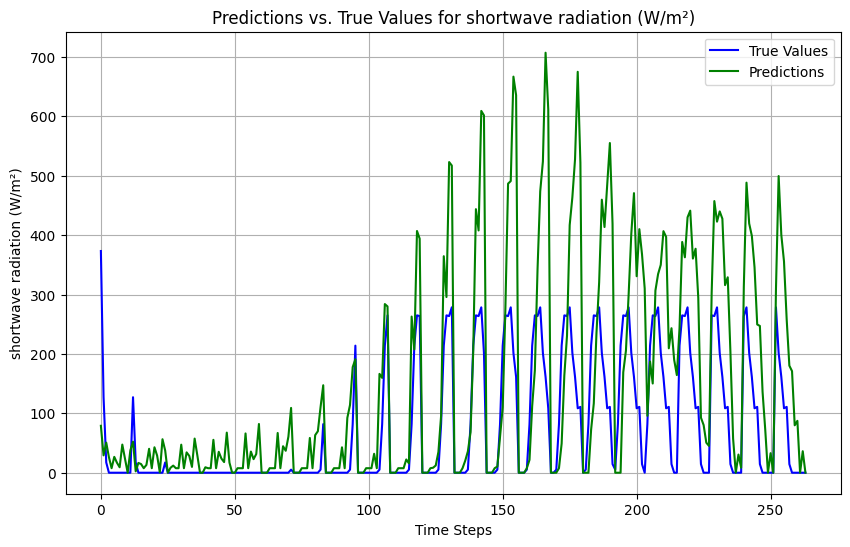

In [31]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for shortwave radiation (W/m²)')
plt.xlabel('Time Steps')
plt.ylabel('shortwave radiation (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

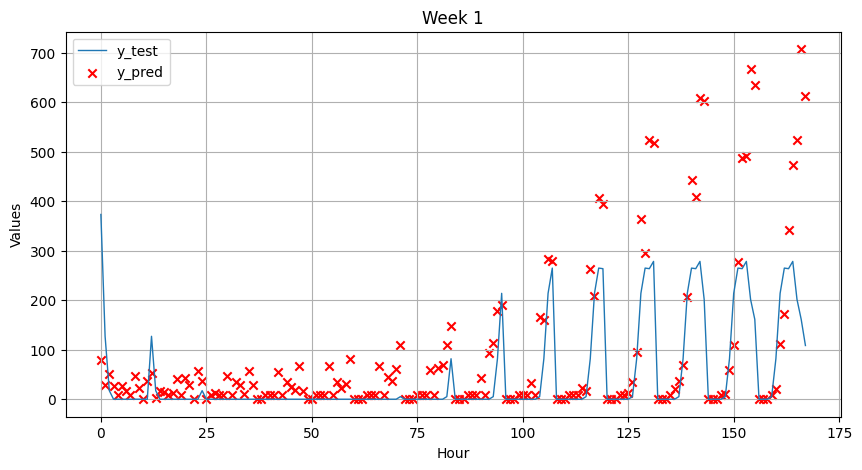

In [32]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()